In [5]:
cols = [
"state_name",
"village_code",
"number_of_total_population",
"number_of_total_household",
"total_number_of_pregnant_women",
"number_of_pregnant_women_receiving_services_under_icds",
"total_number_of_lactating_mothers",
"number_of_lactating_mothers_receiving_services_under_icds",
"number_of_young_anaemic_children_in_icds_common_application_software_659_months",
"number_of_children_under_the_age_of_6_years_who_are_underweight",
"number_of_households_not_having_sanitary_latrines",
"number_of_households_with_kuccha_wall_and_kuccha_roof",
"number_of_children_not_attending_the_school",
"number_of_households_having_bpl_ration_cards",
"total_number_of_newly_born_children_during_the_year_201819",
"number_of_newly_born_children_underweight_during_the_year_201819",
"village_latitude",
"village_longitude"
]

df = df[cols]


In [6]:
df.rename(columns={
"number_of_total_population":"population",
"number_of_total_household":"households",
"total_number_of_pregnant_women":"pregnant_women",
"number_of_pregnant_women_receiving_services_under_icds":"pregnant_icds",
"total_number_of_lactating_mothers":"lactating_mothers",
"number_of_lactating_mothers_receiving_services_under_icds":"lactating_icds",
"number_of_young_anaemic_children_in_icds_common_application_software_659_months":"anaemic_children",
"number_of_children_under_the_age_of_6_years_who_are_underweight":"underweight_children",
"number_of_households_not_having_sanitary_latrines":"no_toilet",
"number_of_households_with_kuccha_wall_and_kuccha_roof":"kuccha_house",
"number_of_children_not_attending_the_school":"children_out_school",
"number_of_households_having_bpl_ration_cards":"bpl_households",
"total_number_of_newly_born_children_during_the_year_201819":"newborns",
"number_of_newly_born_children_underweight_during_the_year_201819":"underweight_births"
}, inplace=True)


In [7]:
for col in df.columns:
    if col not in ["state_name", "village_code"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")


In [8]:
df.fillna(0, inplace=True)


In [9]:
print(df.dtypes)


state_name               object
village_code              int64
population                int64
households                int64
pregnant_women            int64
pregnant_icds             int64
lactating_mothers         int64
lactating_icds            int64
anaemic_children          int64
underweight_children      int64
no_toilet                 int64
kuccha_house              int64
children_out_school     float64
bpl_households          float64
newborns                  int64
underweight_births        int64
village_latitude        float64
village_longitude       float64
dtype: object


In [10]:
df["anaemia_rate"] = df["anaemic_children"] / (df["population"] + 1)

df["underweight_rate"] = df["underweight_children"] / (df["population"] + 1)

df["underweight_birth_rate"] = df["underweight_births"] / (df["newborns"] + 1)


In [11]:
df["pregnant_coverage"] = df["pregnant_icds"] / (df["pregnant_women"] + 1)

df["lactating_coverage"] = df["lactating_icds"] / (df["lactating_mothers"] + 1)


In [12]:
df["sanitation_deficit"] = df["no_toilet"] / (df["households"] + 1)

df["kuccha_rate"] = df["kuccha_house"] / (df["households"] + 1)


In [13]:
df["poverty_rate"] = df["bpl_households"] / (df["households"] + 1)

df["school_dropout_rate"] = df["children_out_school"] / (df["population"] + 1)


In [14]:
df["population_density_proxy"] = df["population"] / (df["households"] + 1)


In [15]:
df["risk_score"] = (
    df["anaemia_rate"]*0.25 +
    df["sanitation_deficit"]*0.20 +
    (1-df["pregnant_coverage"])*0.15 +
    df["underweight_birth_rate"]*0.15 +
    df["poverty_rate"]*0.15 +
    df["school_dropout_rate"]*0.10
)


In [16]:
features = [
"anaemia_rate",
"underweight_rate",
"underweight_birth_rate",
"pregnant_coverage",
"lactating_coverage",
"sanitation_deficit",
"kuccha_rate",
"poverty_rate",
"school_dropout_rate",
"population_density_proxy"
]


In [17]:
q1 = df["risk_score"].quantile(0.33)
q2 = df["risk_score"].quantile(0.66)

def label(x):
    if x >= q2:
        return 2   # High risk
    elif x >= q1:
        return 1   # Medium risk
    else:
        return 0   # Low risk

df["risk_label"] = df["risk_score"].apply(label)


In [18]:
print(df["risk_label"].value_counts())


risk_label
2    10800
0    10190
1     9889
Name: count, dtype: int64


In [19]:
from sklearn.model_selection import train_test_split

X = df[features]
y = df["risk_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200)
}

rows = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, pred, average="weighted", zero_division=0)

    rows.append([name, acc, prec, rec, f1])

# table
results_df = pd.DataFrame(
    rows,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
)

results_df.style.background_gradient(cmap="Blues")


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.971826,0.972397,0.971826,0.971558
1,Random Forest,0.979922,0.979900,0.979922,0.979898


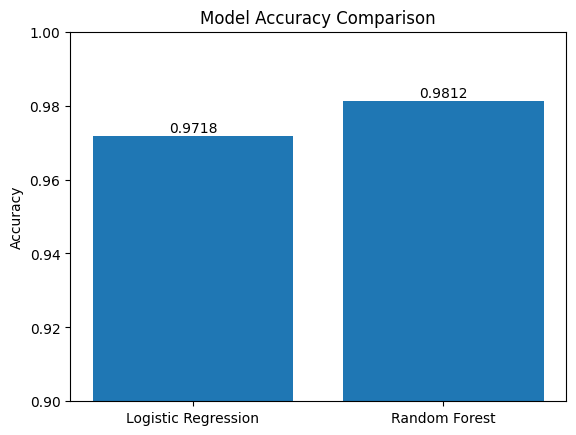

In [21]:
from sklearn.metrics import accuracy_score

results = {}

for name, model in models.items():   # models_dict = your models dictionary
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results[name] = acc

import matplotlib.pyplot as plt

plt.bar(results.keys(), results.values())
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0.9,1.0)

for i, v in enumerate(results.values()):
    plt.text(i, v+0.001, f"{v:.4f}", ha='center')

plt.show()


Random Forest Accuracy: 0.9798


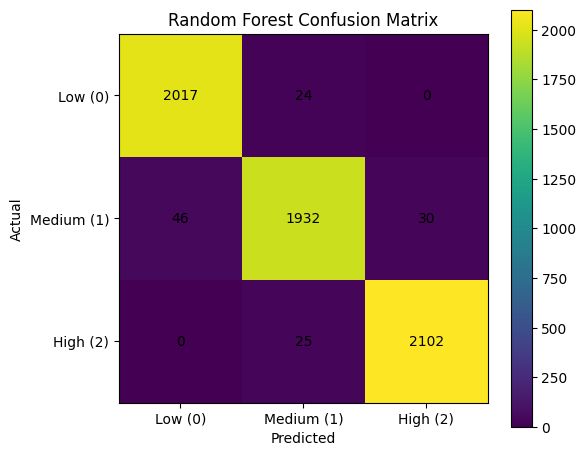

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# Train model
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", round(acc, 4))

# Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)

# Plot
plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.colorbar()

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Label axes (3-class)
classes = ["Low (0)", "Medium (1)", "High (2)"]
plt.xticks(np.arange(3), classes)
plt.yticks(np.arange(3), classes)

# Annotate values inside matrix
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center")

plt.tight_layout()
plt.show()

In [23]:
final_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

final_model.fit(X, y)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [24]:
probs = final_model.predict_proba(X)

high_index = list(final_model.classes_).index(2)
df["predicted_risk"] = probs[:, high_index]


In [25]:
df["predicted_risk"] = (
    0.6 * df["predicted_risk"] +
    0.4 * df["risk_score"]
)


In [26]:
# impact & cost models (tune coefficients if needed)
df["expected_risk_reduction"] = df["predicted_risk"] * 0.3
df["cost"] = df["population"] * 0.05

# utility for ranking
df["utility"] = (df["expected_risk_reduction"] * df["population"]) / (df["cost"] + 1)


In [27]:
df["predicted_risk"].describe()


count    30879.000000
mean         0.251217
std          0.307394
min          0.000159
25%          0.012348
50%          0.036791
75%          0.660000
max          0.796942
Name: predicted_risk, dtype: float64

In [28]:
df.to_csv("final_ai_dataset.csv", index=False)


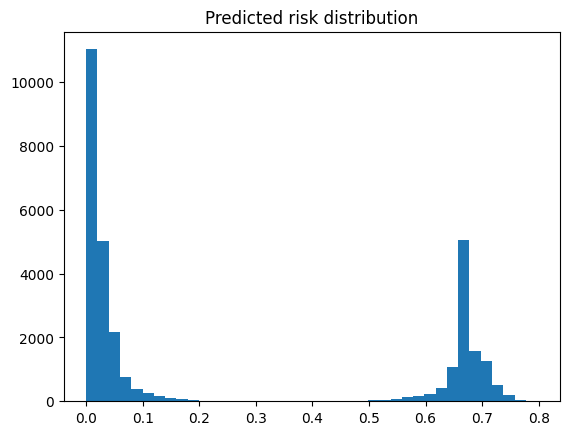

In [29]:
import matplotlib.pyplot as plt
plt.hist(df["predicted_risk"], bins=40)
plt.title("Predicted risk distribution")
plt.show()


In [30]:
df["expected_risk_reduction"] = df["predicted_risk"] * 0.3


In [31]:
df["cost"] = df["population"] * 0.05


In [32]:
df["utility"] = (
    df["expected_risk_reduction"] * df["population"]
) / (df["cost"] + 1)


In [33]:
def allocate_budget(df, budget):
    df_sorted = df.sort_values(by="utility", ascending=False)
    selected = []
    spent = 0.0

    for _, row in df_sorted.iterrows():
        c = float(row["cost"])
        if spent + c <= budget:
            selected.append(row)
            spent += c

    selected_df = pd.DataFrame(selected).sort_values("utility", ascending=False).reset_index(drop=True)
    return selected_df, spent

def allocate_with_fairness(df, budget, min_per_state=3, max_per_state=None):
    df_sorted = df.sort_values(by="utility", ascending=False)
    selected = []
    spent = 0.0
    count_by_state = {}

    # 1) Guarantee minimum per state
    for state, group in df_sorted.groupby("state_name"):
        taken = 0
        for idx, row in group.iterrows():
            if taken >= min_per_state:
                break
            c = float(row["cost"])
            if spent + c <= budget:
                selected.append(row)
                spent += c
                taken += 1
                count_by_state[state] = count_by_state.get(state, 0) + 1

    # 2) Fill remaining budget by utility (respect optional cap)
    remaining = df_sorted.drop(index=[r.name for r in selected])
    for _, row in remaining.iterrows():
        state = row["state_name"]
        if max_per_state is not None and count_by_state.get(state, 0) >= max_per_state:
            continue

        c = float(row["cost"])
        if spent + c <= budget:
            selected.append(row)
            spent += c
            count_by_state[state] = count_by_state.get(state, 0) + 1

    selected_df = pd.DataFrame(selected).sort_values("utility", ascending=False).reset_index(drop=True)
    return selected_df, spent, count_by_state



In [34]:
budget_input = float(input("Enter budget amount: "))
min_state = int(input("Minimum villages per state (e.g., 3): "))
cap_state = input("Max villages per state (blank for no cap): ")

max_state = None if cap_state.strip()=="" else int(cap_state)

selected_df, spent, counts = allocate_with_fairness(
    df, budget_input, min_per_state=min_state, max_per_state=max_state
)

print("Budget:", budget_input)
print("Spent:", round(spent,2))
print("Villages selected:", len(selected_df))
print("Per-state counts:", counts)

selected_df[["village_code","state_name","predicted_risk","utility"]].head(10)


Enter budget amount:  5000
Minimum villages per state (e.g., 3):  3
Max villages per state (blank for no cap):  


Budget: 5000.0
Spent: 4999.95
Villages selected: 38
Per-state counts: {'Aasam': 3, 'Bihar': 3, 'Chattisgarh': 3, 'GJ': 3, 'Goa': 3, 'Haryana': 3, 'Jharkhand': 3, 'Ladakh': 3, 'Maharashtra': 3, 'Manipur': 3, 'Misoram': 3, 'Nagaland': 3, 'Odisha': 2}


,village_code,state_name,predicted_risk,utility
0,980,Ladakh,0.795289,4.721953
1,375850,Jharkhand,0.780888,4.632801
2,267955,Nagaland,0.789509,4.625857
3,935282,Manipur,0.781420,4.611657
4,450540,Chattisgarh,0.792910,4.606187
5,267636,Nagaland,0.792337,4.567957
6,286763,Aasam,0.763810,4.550504
7,267024,Nagaland,0.764910,4.548794
8,522706,GJ,0.756118,4.497275
9,283048,Aasam,0.751800,4.490923


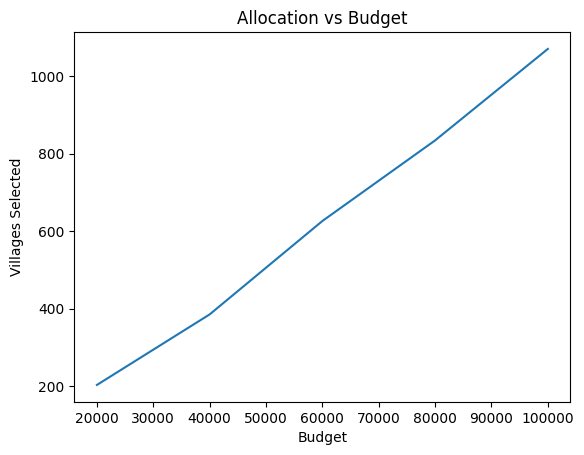

In [35]:
import matplotlib.pyplot as plt

budgets = [20000, 40000, 60000, 80000, 100000]
counts = []

for b in budgets:
    sel, spent = allocate_budget(df, b)  # your function
    counts.append(len(sel))

plt.plot(budgets, counts)
plt.xlabel("Budget")
plt.ylabel("Villages Selected")
plt.title("Allocation vs Budget")
plt.show()


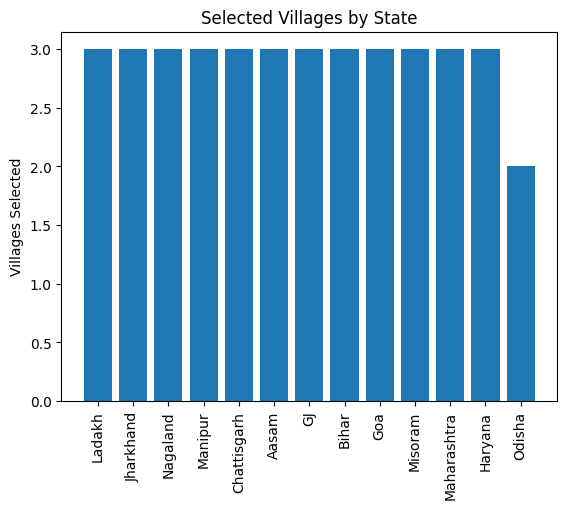

In [36]:
state_counts = selected_df["state_name"].value_counts()

plt.bar(state_counts.index, state_counts.values)
plt.xticks(rotation=90)
plt.ylabel("Villages Selected")
plt.title("Selected Villages by State")
plt.show()


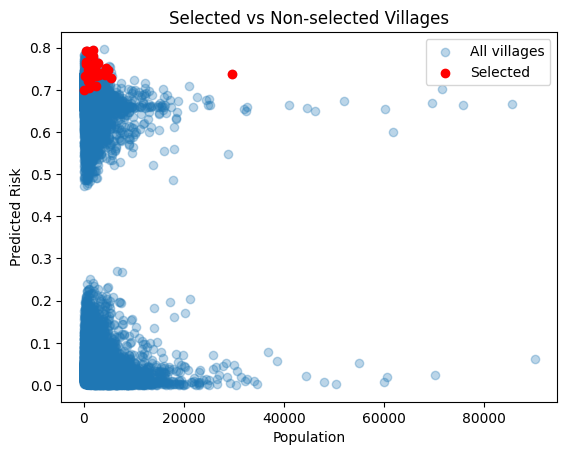

In [37]:
plt.scatter(df["population"], df["predicted_risk"], alpha=0.3, label="All villages")
plt.scatter(selected_df["population"], selected_df["predicted_risk"], color="red", label="Selected")

plt.xlabel("Population")
plt.ylabel("Predicted Risk")
plt.legend()
plt.title("Selected vs Non-selected Villages")
plt.show()


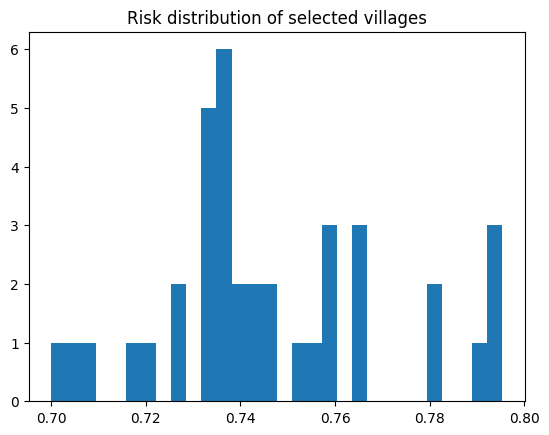

In [38]:
plt.hist(selected_df["predicted_risk"], bins=30)
plt.title("Risk distribution of selected villages")
plt.show()


In [39]:
selected_df, spent = allocate_budget(df, budget_input)


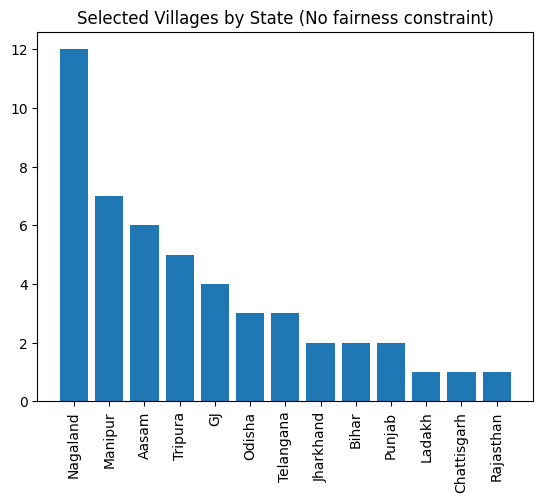

In [40]:
state_counts = selected_df["state_name"].value_counts()

plt.bar(state_counts.index, state_counts.values)
plt.xticks(rotation=90)
plt.title("Selected Villages by State (No fairness constraint)")
plt.show()


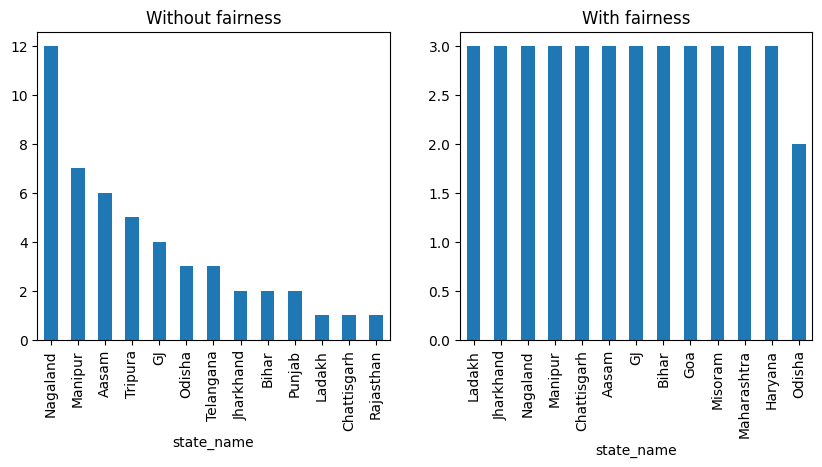

In [41]:
# without fairness
sel1, _ = allocate_budget(df, budget_input)
counts1 = sel1["state_name"].value_counts()

# with fairness
sel2, _, _ = allocate_with_fairness(df, budget_input, min_per_state=3)
counts2 = sel2["state_name"].value_counts()

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
counts1.plot(kind="bar")
plt.title("Without fairness")

plt.subplot(1,2,2)
counts2.plot(kind="bar")
plt.title("With fairness")

plt.show()


In [42]:
import folium


#Filter invalid coordinates 
map_df = selected_df[
    (selected_df["village_latitude"].between(5, 40)) &
    (selected_df["village_longitude"].between(65, 100))
].copy()

#Color function
def get_color(risk):
    if risk >= 0.7:
        return "red"
    elif risk >= 0.4:
        return "orange"
    else:
        return "green"

#Create map
m = folium.Map(location=[22.5, 78.9], zoom_start=5, tiles="CartoDB positron")

for _, row in map_df.iterrows():
    folium.CircleMarker(
        location=[row["village_latitude"], row["village_longitude"]],
        radius=4,
        color=get_color(row["predicted_risk"]),
        fill=True,
        fill_opacity=0.8,
        popup=f"{row['state_name']} | risk={row['predicted_risk']:.2f}"
    ).add_to(m)

#Show map
m


In [43]:
import numpy as np
import pandas as pd

# Generate 5 synthetic villages using mean ± random noise
synthetic_samples = []

for i in range(5):
    sample = {}
    for col in features:
        mean = df[col].mean()
        std = df[col].std()
        value = np.random.normal(mean, std)
        sample[col] = max(0, value)  # avoid negative values
    synthetic_samples.append(sample)

new_data = pd.DataFrame(synthetic_samples)
new_data

,anaemia_rate,underweight_rate,underweight_birth_rate,pregnant_coverage,lactating_coverage,sanitation_deficit,kuccha_rate,poverty_rate,school_dropout_rate,population_density_proxy
0,0.000000,0.040929,0.366368,0.566817,0.000000,0.000000,0.515275,0,0,1.055860
1,0.027762,0.005325,0.000000,0.884830,0.011964,0.000000,0.216684,0,0,23.527267
2,0.049343,0.029683,0.000000,0.105470,0.626386,0.204178,0.000000,0,0,0.000000
3,0.001179,0.000000,0.098659,0.047640,1.089822,0.030181,0.359510,0,0,1.304900
4,0.000000,0.000000,0.072891,1.537902,0.976177,0.405579,0.228625,0,0,7.303595


In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [45]:
# Correct predictions on 5 new inputs
log_pred = log_model.predict(new_data)
rf_pred = rf_model.predict(new_data)

log_prob = log_model.predict_proba(new_data)
rf_prob = rf_model.predict_proba(new_data)

In [46]:
label_map = {0: "Low", 1: "Medium", 2: "High"}
# Map numeric predictions to text
log_pred_labels = pd.Series(log_pred).map(label_map)
rf_pred_labels = pd.Series(rf_pred).map(label_map)# Confidence = max predicted probability

log_confidence = log_prob.max(axis=1)
rf_confidence = rf_prob.max(axis=1)

In [61]:
import pandas as pd

# Map numeric labels to risk classes
label_map = {0: "Low", 1: "Medium", 2: "High"}

# Convert predictions to labels
log_labels = pd.Series(log_pred).map(label_map)
rf_labels = pd.Series(rf_pred).map(label_map)

# Create comparison table
classification_table = pd.DataFrame({
    "Village": [f"Village {i+1}" for i in range(len(log_pred))],
    "Logistic_Regression_Risk": log_labels,
    "Random_Forest_Risk": rf_labels
})

classification_table

,Village,Logistic_Regression_Risk,Random_Forest_Risk
0,Village 1,Medium,Medium
1,Village 2,Low,Low
2,Village 3,High,High
3,Village 4,High,High
4,Village 5,Low,Medium


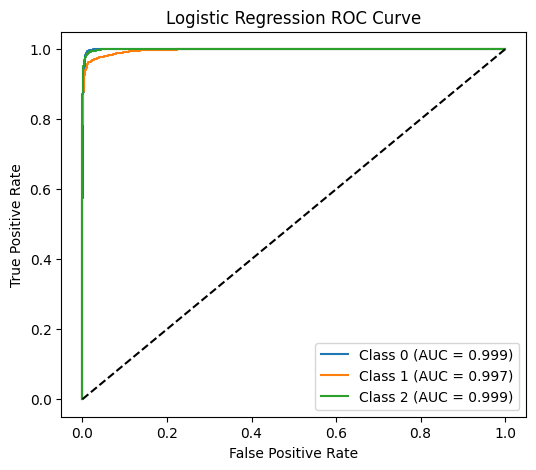

In [49]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Binarize labels
y_test_bin = label_binarize(y_test, classes=[0,1,2])

# Get probability scores
log_prob_full = log_model.predict_proba(X_test)

plt.figure(figsize=(6,5))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], log_prob_full[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend()
plt.show()

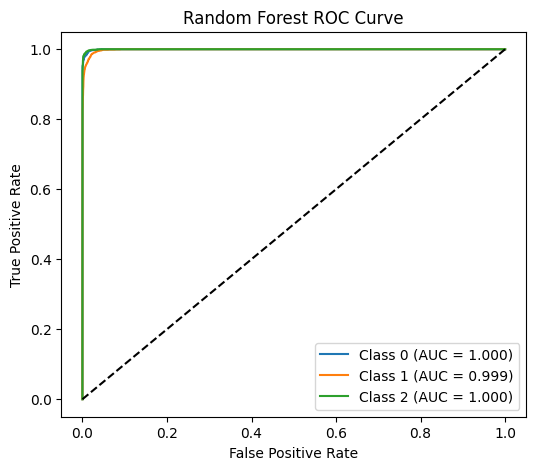

In [50]:
rf_prob_full = rf_model.predict_proba(X_test)

plt.figure(figsize=(6,5))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], rf_prob_full[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.show()

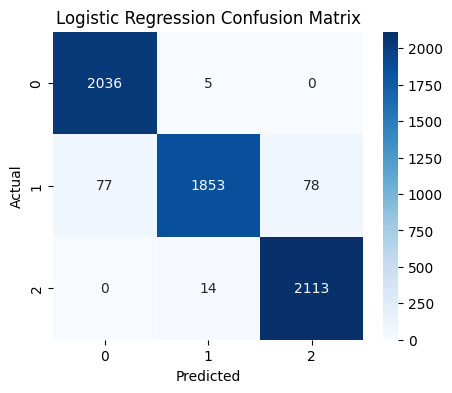

In [51]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

log_cm = confusion_matrix(y_test, log_model.predict(X_test))

plt.figure(figsize=(5,4))
sns.heatmap(log_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

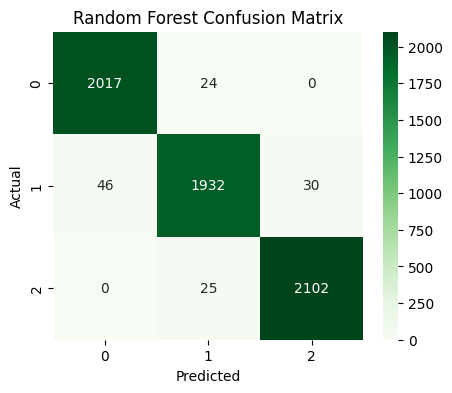

In [52]:
rf_cm = confusion_matrix(y_test, rf_model.predict(X_test))

plt.figure(figsize=(5,4))
sns.heatmap(rf_cm, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Logistic Regression Error Rate: 0.0282
Random Forest Error Rate: 0.0202


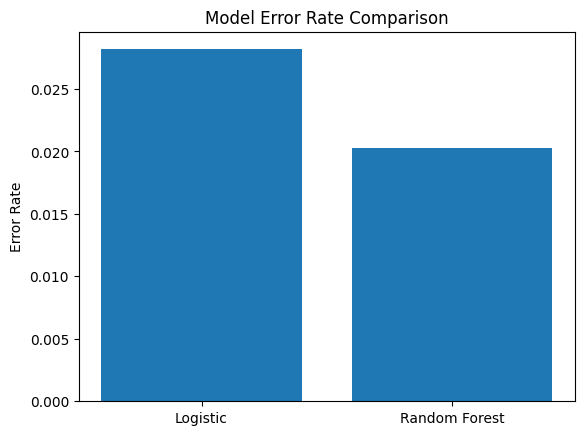

In [53]:
from sklearn.metrics import accuracy_score

log_acc = accuracy_score(y_test, log_model.predict(X_test))
rf_acc = accuracy_score(y_test, rf_model.predict(X_test))

log_error = 1 - log_acc
rf_error = 1 - rf_acc

print("Logistic Regression Error Rate:", round(log_error,4))
print("Random Forest Error Rate:", round(rf_error,4))

plt.bar(["Logistic","Random Forest"], [log_error, rf_error])
plt.ylabel("Error Rate")
plt.title("Model Error Rate Comparison")
plt.show()

Logistic Training Time: 5.1438 seconds
Random Forest Training Time: 17.0815 seconds


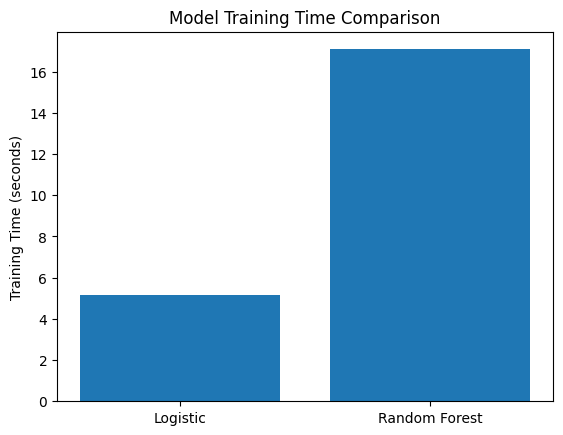

In [54]:
import time

# Logistic Regression timing
start = time.time()
log_model.fit(X_train, y_train)
log_time = time.time() - start

# Random Forest timing
start = time.time()
rf_model.fit(X_train, y_train)
rf_time = time.time() - start

print("Logistic Training Time:", round(log_time,4), "seconds")
print("Random Forest Training Time:", round(rf_time,4), "seconds")

plt.bar(["Logistic","Random Forest"], [log_time, rf_time])
plt.ylabel("Training Time (seconds)")
plt.title("Model Training Time Comparison")
plt.show()

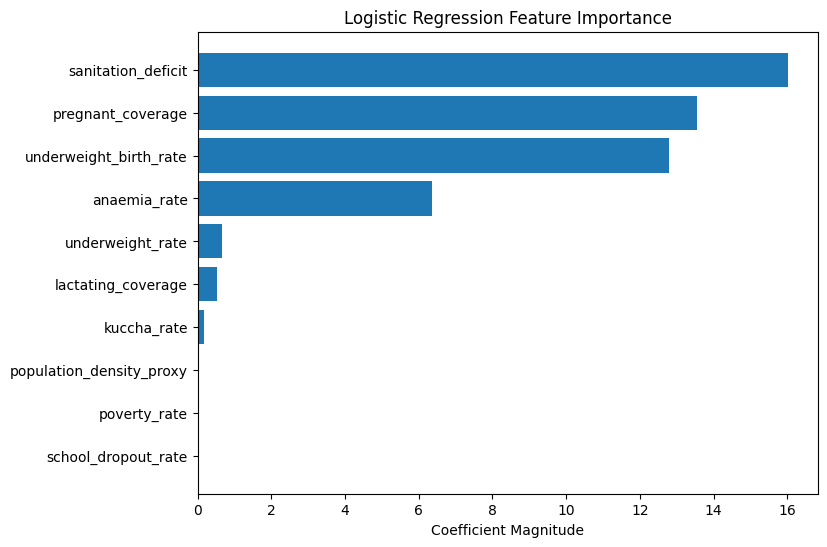

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Get feature names
feature_names = X.columns

# Multiclass → average absolute coefficient across classes
log_importance = np.mean(np.abs(log_model.coef_), axis=0)

log_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": log_importance
}).sort_values(by="Importance", ascending=False)

# Plot
plt.figure(figsize=(8,6))
plt.barh(log_importance_df["Feature"], log_importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Logistic Regression Feature Importance")
plt.xlabel("Coefficient Magnitude")
plt.show()

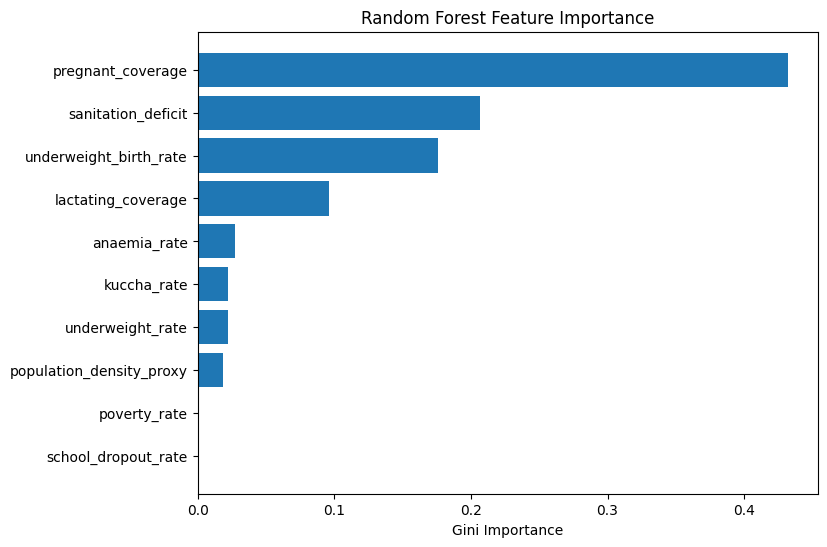

In [56]:
rf_importance = rf_model.feature_importances_

rf_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_importance
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,6))
plt.barh(rf_importance_df["Feature"], rf_importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.xlabel("Gini Importance")
plt.show()